   <center>
</center>
   <center>
    <h3 style = "color:green">Lab 7 Implementing a Perceptron Learning Algorithm in Python</h3>
</center>
    <img src="images/machine_learning.jpg" width=200; height=200>
    
### by Joshua Brewington

<h2><u>Objectives</u></h2>

- Reuse and modify code from Activity 10 (Pre-Lab 7).
- Reuse code from other lab(s)
- Understand the McCulloch and Pitts (MCP) simplified model of a neuron
- Mathematically Implement Frank Rosenblatt’s perceptron learning rule based on
the MCP neuron model (use some Linear Algebra)
- Use the Python Programming Language to Implement Frank Rosenblatt’s
perceptron learning rule based on the MCP neuron model.
- Use NumPy matrix products and other Numpy features (arrays and methods)
- Train the MCP model for binary classification on subset of Iris flower dataset

## Implementing a Perceptron Learning Algorithm in Python

The COMPLETE Perceptron Class1 that we reviewed in the lectures is included below for your convenience (carefully examine the code. see next page for explanation on how the fit method works):

In [1]:
import numpy as np

class Perceptron(object):
    """Percepttron classifier.
    
    Parameters
    ------------
    eta : float
        Learning rate (between 0.0 and 1.0)
    n_iter : int
        Passes over the training dataset.
        
    Attributes
    ------------
    w_ : 1d-array
        Weights after fitting.
    errors_ : list
        Number of misclassifications in every epoch.
    """
    def __init__(self, eta=0.01, n_iter=10):
        self.eta = eta
        self.n_iter = n_iter
        
    def fit(self, X, y):
    #This function is called __init__ and has variables of 'eta' and 'n_iter'.
    #eta and n_iter arguments passed to the constructor as instance variables.
        """Fit training data.
        
        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
            Training vectors, where n_samples is the number of samples and
            n_features is the number of features.
        y : array-like, shape = [n_samples]
            Target values.
            
        Returns
        -------
        self : object
        """
        #self.w_ = np.zeros(1 + X.shape[1])
        #self.w_ = np.array([.5,.5,.5])
        #self.w_ = np.array([2,-2,3], dtype=np.float64)
        #self.w_ = np.array([-4,4,1], dtype=np.float64)
        self.w_ = np.array([1,2,3], dtype=np.float64)
        # Weights are initialized
        self.errors_ = []
        
        for _ in range(self.n_iter):
            # for loop that will keep going 'n_iter' times
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                #This calculates the update to the weight vector
                self.w_[1:] += update * xi
                self.w_[0] += update
                #This updates the bias term
                errors += int(update != 0.0)
            self.errors_.append(errors)
            # This adds the number of errors or misclassifications
        return self
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X)>=0.0,1,-1)

This cell is defining a perceptron classifer. A perceptron classifier takes in inputted features, applies a weight and returns a binary output (-1 or 1) depending on the weights convergence. The model is defined by its weights which is initialized by self.w_ = np.array([1,2,3], dtype=np.float64). Above that line of code, there are other weights that are commented out. These previous weights were used to run different test runs with varying learning weights. This was done to see the difference in convergences. From here, these weigts are then ran through the for loop below. It runs it through the mathematical function of the update variable, and then the number of 'errors' are counted. These are then added up through 'append'.

## Load the iris flower Dataset

Load the iris flower dataset from the UCI Machine Learning Repository into a Pandas Dataframe.

In [2]:
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/'
                'machine-learning-databases/iris/iris.data', header=None)
df.tail()
# Here we are loading the dataset from UCI Machine Learning repository

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Next, extract the first 100 class labels (this corresponds to 50 Iris-Setosa and 50 Iris_Veriscolor flowers, respectively)

Using matplotlib, we are extracting the first 100 columns for the first row.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# select setosa and versicolor
y = df.iloc[0:100,4].values

### Class Label Encoding

Now, let's encode the class labels as integers to use with our Perceptron model we will develop in the lab. This means we will convert them as follows: 1b = Veriscolor and -1 = Setosa. We will use Numpy to do this as follows:

Here we are encoding the class labels into integers.

In [4]:
y = np.where(y == 'Iris-setosa', -1, 1)
# this is the y vector for Iris-setosa

To keep the analyis simple, we will only use two features from the reduced dataset. Let's extract the first feature column (sepal length) and the third feature column (petal length) to use in our analysis.

We are simplifying the features to make the process easier.

In [5]:
# extract sepal length and petal length
X = df.iloc[0:100,[0,2]].values

We now have extracted the subset of data from the Iris flower dataset and can proceed with plotting it. We examine the data to see if it is linearly separable with a well-defined decision boundary. Before we proceed make sure you understand what is occuring with the new NumPy and Pandas commands:

    1. The numpy np.where command
    2. The Pandas df.iloc command
    3. The numpy np.zeros command (see below)

### Decision Boundary Plotting

We can better visualize the data by a simply plot. Note the use of python lists in the code below and make sure you know what is occuring.

Below we are displaying the first 50 versicolors and 50 setosa to get a decison boundary plot.

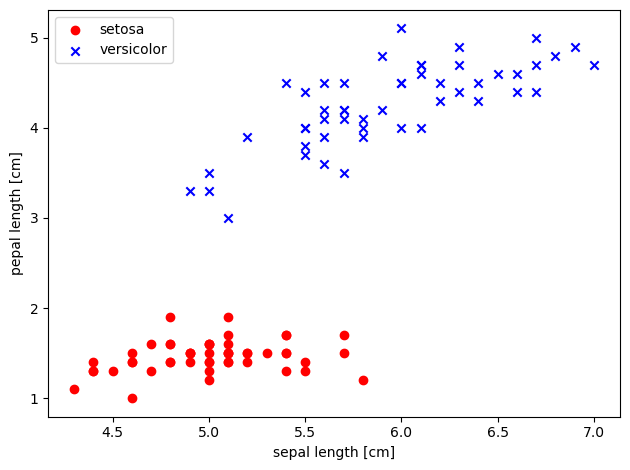

In [6]:
# plot data
plt.scatter(X[:50,0], X[:50,1],
            color='red', marker='o', label='setosa')
plt.scatter(X[50:100,0], X[50:100,1],
            color='blue', marker='x', label='versicolor')

plt.xlabel('sepal length [cm]')
plt.ylabel('pepal length [cm]')
plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('iris_decision_boundary.png', dpi=300)
plt.show()

## Training the Perceptron Model:
Instantiate the class with the default values and call the fit method:

In [7]:
ppn = Perceptron(eta=0.4, n_iter=10)
ppn.fit(X,y)

#This is training the model with 10 iterations.

Make sure you plot the misclassifications (errors) after each epoch so that we can see 
how many epochs it took before the algorithm converged.

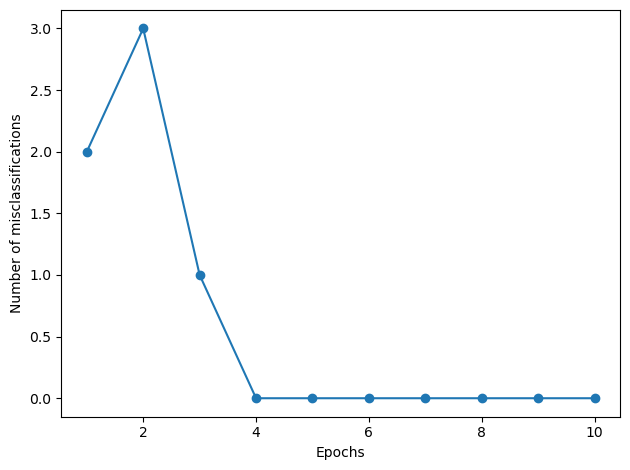

In [8]:
plt.plot(range(1, len(ppn.errors_)+ 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of misclassifications')

plt.tight_layout()
plt.savefig('perceptron_1.png',dpi=300)
plt.show()
#This is plotting the number of missclassifications until it converges.

## Epochs to Convergence Table


<table>
  <tr>
    <td>Run #</td>
    <td>n</td>
    <td>Epochs to convergene</td>
    <td>Wo</td>
    <td>W1</td>
    <td>w2</td>
  </tr>
  <tr>
    <td>1</td>
    <td>0.05</td>
    <td>6</td>
    <td>0</td>
    <td>0</td>
    <td>0</td>
  </tr>
  <tr>
    <td>2</td>
    <td>0.1</td>
    <td>4</td>
    <td>0.5</td>
    <td>0.5</td>
    <td>0.5</td>
  </tr>
  <tr>
    <td>3</td>
    <td>0.05</td>
    <td>It never converges</td>
    <td>2</td>
    <td>-2</td>
    <td>3</td>
  </tr>
  <tr>
    <td>4</td>
    <td>0.05</td>
    <td>5</td>
    <td>-4</td>
    <td>4</td>
    <td>1</td>
  </tr>
  <tr>
    <td>5</td>
    <td>0.4</td>
    <td>4</td>
    <td>1</td>
    <td>2</td>
    <td>3</td>
  </tr>
</table>

## Questions:
 
- It is important that you understand every line of code in this lab. In the labs that follows, we will use these techniques with our Perceptron model. 
- Explain what the code snippets below from our Perceptron Class are doing (assume we are using the feature matrix from this lab)
    
    i. self.w_[1:] += update * xi
    
    ii. errors += int(update != 0.0)

**i:** The first one updates the weights by using 'update' and the feature vector 'xi'. The 'update' is equivocated from the product of the learning rate 'self.eta' and the difference between 'target' and 'self.predict(xi)'.

**ii.** This counts the error count by 1 if there is a misclassification. This happens when the predicted class label differs from the true class. The 'update' condition adds either a 1 or 0 (boolean statement) to add to the 'errors'.